            # Fog Removal For Autonomous Vehicles

            **One-stop project notebook** for the winter driving fog-removal system.

            This notebook does two jobs in one place:
            - walks through the training runs, assets, metrics, and qualitative comparisons,
            - runs the final `300`-epoch `DehazeFormer-S` checkpoint on a video and returns the restored result.
            

In [ ]:
import importlib.util
import os
import shutil
import subprocess
import sys
from tqdm.auto import tqdm
from pathlib import Path

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "PIL": "pillow",
    "cv2": "opencv-python-headless",
    "torch": "torch",
    "timm": "timm",
    "pytorch_msssim": "pytorch-msssim",
    "IPython": "ipython",
    "huggingface_hub": "huggingface_hub",
}

missing = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    uv = shutil.which("uv")
    if uv is not None:
        subprocess.check_call([uv, "pip", "install", "--python", sys.executable, *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

In [ ]:
import csv
import json
import math
import os
import shutil
import subprocess
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings(
    "ignore",
    message="Passing `palette` without assigning `hue` is deprecated.*",
    category=FutureWarning,
)
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
from huggingface_hub import hf_hub_download
from IPython.display import HTML, Markdown, Video, display
from PIL import Image

if Path.cwd().name == "notebooks":
    ROOT = Path.cwd().resolve().parent
else:
    ROOT = Path.cwd().resolve()

NOTEBOOK_DIR = ROOT / "notebooks"
ASSETS = NOTEBOOK_DIR / "assets"
RUNS = ROOT / "runs" / "modal"

sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ASSETS = {
    "final_checkpoint": RUNS / "dehazeformer_s_reside_300ep" / "dehazeformer-s.pth",
    "final_eval_json": RUNS / "dehazeformer_s_reside_300ep" / "eval_result.json",
    "demo_checkpoint": RUNS / "dehazeformer_s_reside_demo" / "dehazeformer-s.pth",
    "demo_eval_json": RUNS / "dehazeformer_s_reside_demo" / "eval_result.json",
    "fallback_checkpoint": RUNS / "dehazeformer_s_reside_15ep" / "dehazeformer-s.pth",
    "fallback_eval_json": RUNS / "dehazeformer_s_reside_15ep" / "eval_result.json",
    "default_input_video": ROOT / "runs" / "test_assets" / "hazy.mp4",
    "default_reference_video": ROOT / "runs" / "test_assets" / "clear.mp4",
}

HF_REPO_ID = "Pranavz/minor32-fog-removal"
DEHAZEFORMER_REPO_URL = "https://github.com/IDKiro/DehazeFormer.git"
DEHAZEFORMER_REPO_REF = "5af7c34d6f8e0784a88a2132a7add296bf99ca9c"

PUBLISHED_ASSETS = {
    RUNS / "dehazeformer_s_reside_300ep" / "dehazeformer-s.pth": "checkpoints/dehazeformer_s_reside_300ep.pth",
    RUNS / "dehazeformer_s_reside_demo" / "dehazeformer-s.pth": "checkpoints/dehazeformer_s_reside_50ep.pth",
    RUNS / "dehazeformer_s_reside_15ep" / "dehazeformer-s.pth": "checkpoints/dehazeformer_s_reside_15ep.pth",
    RUNS / "dehazeformer_s_reside_300ep" / "eval_result.json": "metrics/dehazeformer_s_reside_300ep_eval.json",
    RUNS / "dehazeformer_s_reside_demo" / "eval_result.json": "metrics/dehazeformer_s_reside_50ep_eval.json",
    RUNS / "dehazeformer_s_reside_15ep" / "eval_result.json": "metrics/dehazeformer_s_reside_15ep_eval.json",
    ASSETS / "tables" / "300ep_results.csv": "notebook_assets/tables/300ep_results.csv",
    ASSETS / "tables" / "demo_results.csv": "notebook_assets/tables/demo_results.csv",
    ASSETS / "tables" / "15ep_results.csv": "notebook_assets/tables/15ep_results.csv",
    ASSETS / "300ep" / "1400_1.png": "notebook_assets/300ep/1400_1.png",
    ASSETS / "300ep" / "1425_5.png": "notebook_assets/300ep/1425_5.png",
    ASSETS / "300ep" / "1449_10.png": "notebook_assets/300ep/1449_10.png",
    ASSETS / "demo" / "1400_1.png": "notebook_assets/demo/1400_1.png",
    ASSETS / "demo" / "1425_5.png": "notebook_assets/demo/1425_5.png",
    ASSETS / "demo" / "1449_10.png": "notebook_assets/demo/1449_10.png",
    ASSETS / "15ep" / "1400_1.png": "notebook_assets/15ep/1400_1.png",
    ASSETS / "15ep" / "1425_5.png": "notebook_assets/15ep/1425_5.png",
    ASSETS / "15ep" / "1449_10.png": "notebook_assets/15ep/1449_10.png",
    ASSETS / "dataset" / "1400_1_hazy.png": "notebook_assets/dataset/1400_1_hazy.png",
    ASSETS / "dataset" / "1425_5_hazy.png": "notebook_assets/dataset/1425_5_hazy.png",
    ASSETS / "dataset" / "1449_10_hazy.png": "notebook_assets/dataset/1449_10_hazy.png",
    ASSETS / "dataset" / "1400_1_gt.png": "notebook_assets/dataset/1400_1_gt.png",
    ASSETS / "dataset" / "1425_5_gt.png": "notebook_assets/dataset/1425_5_gt.png",
    ASSETS / "dataset" / "1449_10_gt.png": "notebook_assets/dataset/1449_10_gt.png",
    ROOT / "runs" / "test_assets" / "hazy.mp4": "demo_inputs/hazy.mp4",
    ROOT / "runs" / "test_assets" / "clear.mp4": "demo_inputs/clear.mp4",
}

def ensure_published_asset(local_path: Path, repo_path: str) -> Path:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists():
        return local_path
    downloaded = hf_hub_download(
        repo_id=HF_REPO_ID,
        repo_type="model",
        filename=repo_path,
        local_dir=str(local_path.parent),
        local_dir_use_symlinks=False,
    )
    downloaded_path = Path(downloaded)
    if downloaded_path != local_path and downloaded_path.exists():
        downloaded_path.replace(local_path)
    return local_path

for local_path, repo_path in PUBLISHED_ASSETS.items():
    ensure_published_asset(local_path, repo_path)

def write_json(path: str | Path, payload: dict[str, Any]) -> None:
    target = Path(path)
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(json.dumps(payload, indent=2, sort_keys=True))

def write_markdown(path: str | Path, content: str) -> None:
    target = Path(path)
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(content)

def build_demo_markdown(payload: dict[str, Any], title: str) -> str:
    summary = payload.get("summary", {})
    lines = [f"# {title}", "", "## Summary", ""]
    for key, value in summary.items():
        rendered = f"{value:.4f}" if isinstance(value, float) else str(value)
        lines.append(f"- {key}: {rendered}")
    lines.extend(
        [
            "",
            "## Pipeline",
            "",
            f"- input_video: {payload.get('input_video', 'n/a')}",
            f"- output_video: {payload.get('output_video', 'n/a')}",
            f"- mode: {payload.get('pipeline', {}).get('mode', 'n/a')}",
            f"- temporal_alpha: {payload.get('pipeline', {}).get('temporal_alpha', 'n/a')}",
            f"- model_name: {payload.get('pipeline', {}).get('model_name', 'n/a')}",
        ]
    )
    return "\n".join(lines) + "\n"

def psnr(reference: np.ndarray, prediction: np.ndarray) -> float:
    reference_f = reference.astype(np.float32)
    prediction_f = prediction.astype(np.float32)
    mse = float(np.mean((reference_f - prediction_f) ** 2))
    if mse <= 1e-12:
        return float("inf")
    return 20.0 * math.log10(255.0 / math.sqrt(mse))

def ssim(reference: np.ndarray, prediction: np.ndarray) -> float:
    ref = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY).astype(np.float32)
    pred = cv2.cvtColor(prediction, cv2.COLOR_BGR2GRAY).astype(np.float32)
    c1 = (0.01 * 255) ** 2
    c2 = (0.03 * 255) ** 2
    mu_ref = cv2.GaussianBlur(ref, (11, 11), 1.5)
    mu_pred = cv2.GaussianBlur(pred, (11, 11), 1.5)
    mu_ref_sq = mu_ref * mu_ref
    mu_pred_sq = mu_pred * mu_pred
    mu_ref_pred = mu_ref * mu_pred
    sigma_ref_sq = cv2.GaussianBlur(ref * ref, (11, 11), 1.5) - mu_ref_sq
    sigma_pred_sq = cv2.GaussianBlur(pred * pred, (11, 11), 1.5) - mu_pred_sq
    sigma_ref_pred = cv2.GaussianBlur(ref * pred, (11, 11), 1.5) - mu_ref_pred
    numerator = (2 * mu_ref_pred + c1) * (2 * sigma_ref_pred + c2)
    denominator = (mu_ref_sq + mu_pred_sq + c1) * (sigma_ref_sq + sigma_pred_sq + c2)
    score = numerator / np.maximum(denominator, 1e-12)
    return float(np.mean(score))

def temporal_delta(previous_frame: np.ndarray, current_frame: np.ndarray) -> float:
    previous_gray = cv2.cvtColor(previous_frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    current_gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    return float(np.mean(np.abs(current_gray - previous_gray)))

def sharpness(frame: np.ndarray) -> float:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_32F)
    return float(laplacian.var())

def contrast(frame: np.ndarray) -> float:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    return float(gray.std())

def summarize_metrics(samples: list[dict[str, Any]]) -> dict[str, float]:
    summary: dict[str, float] = {}
    if not samples:
        return summary
    keys = sorted(samples[0].keys())
    for key in keys:
        values = [sample[key] for sample in samples if key in sample]
        if values:
            summary[key] = float(np.mean(values))
    return summary

def temporal_smooth(previous_output: np.ndarray | None, current_output: np.ndarray, alpha: float) -> np.ndarray:
    if previous_output is None:
        return current_output
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return cv2.addWeighted(current_output, 1.0 - alpha, previous_output, alpha, 0.0)

@dataclass(slots=True)
class DehazeFormerBundle:
    model_name: str
    checkpoint_path: Path
    upstream_root: Path
    device: str
    network: torch.nn.Module

def _run_command(command: list[str], cwd: Path | None = None) -> None:
    subprocess.check_call(command, cwd=str(cwd) if cwd else None)

def ensure_dehazeformer_upstream(upstream_root: str | Path | None = None) -> Path:
    candidate = Path(upstream_root) if upstream_root is not None else (ROOT / ".standalone_cache" / "dehazeformer")
    if not candidate.exists():
        candidate.parent.mkdir(parents=True, exist_ok=True)
        _run_command(["git", "clone", DEHAZEFORMER_REPO_URL, str(candidate)])
    _run_command(["git", "fetch", "--all", "--tags", "--prune"], cwd=candidate)
    _run_command(["git", "checkout", DEHAZEFORMER_REPO_REF], cwd=candidate)
    return candidate.resolve()

def _load_model_registry(upstream_root: Path) -> dict[str, Any]:
    if str(upstream_root) not in sys.path:
        sys.path.insert(0, str(upstream_root))
    from models import (
        dehazeformer_b,
        dehazeformer_d,
        dehazeformer_l,
        dehazeformer_m,
        dehazeformer_s,
        dehazeformer_t,
        dehazeformer_w,
    )
    return {
        "dehazeformer-t": dehazeformer_t,
        "dehazeformer-s": dehazeformer_s,
        "dehazeformer-b": dehazeformer_b,
        "dehazeformer-d": dehazeformer_d,
        "dehazeformer-w": dehazeformer_w,
        "dehazeformer-m": dehazeformer_m,
        "dehazeformer-l": dehazeformer_l,
    }

def load_dehazeformer(
    checkpoint_path: str | Path,
    model_name: str = "dehazeformer-s",
    upstream_root: str | Path | None = None,
    device: str | None = None,
) -> DehazeFormerBundle:
    checkpoint = Path(checkpoint_path).resolve()
    resolved_upstream = ensure_dehazeformer_upstream(upstream_root)
    registry = _load_model_registry(resolved_upstream)
    torch_device = torch.device(device if device else ("cuda" if torch.cuda.is_available() else "cpu"))
    network = registry[model_name]().to(torch_device)
    payload = torch.load(checkpoint, map_location=torch_device)
    state_dict = payload["state_dict"] if isinstance(payload, dict) and "state_dict" in payload else payload
    cleaned = {}
    for key, value in state_dict.items():
        cleaned[key[7:] if key.startswith("module.") else key] = value
    network.load_state_dict(cleaned, strict=True)
    network.eval()
    return DehazeFormerBundle(
        model_name=model_name,
        checkpoint_path=checkpoint,
        upstream_root=resolved_upstream,
        device=str(torch_device),
        network=network,
    )

def dehaze_frame(frame_bgr: np.ndarray, bundle: DehazeFormerBundle) -> np.ndarray:
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    tensor = torch.from_numpy(np.transpose(rgb * 2.0 - 1.0, (2, 0, 1))).unsqueeze(0).to(bundle.device)
    with torch.no_grad():
        if bundle.device.startswith("cuda"):
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                output = bundle.network(tensor)
        else:
            output = bundle.network(tensor)
        output = output.clamp_(-1, 1)
        output = output * 0.5 + 0.5
    output_rgb = output.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
    output_u8 = np.clip(np.round(output_rgb * 255.0), 0, 255).astype(np.uint8)
    return cv2.cvtColor(output_u8, cv2.COLOR_RGB2BGR)

def _maybe_preserve_audio(input_path: Path, output_path: Path) -> None:
    ffmpeg = shutil.which("ffmpeg")
    if not ffmpeg:
        return
    remux_path = output_path.with_name(f"{output_path.stem}.audio{output_path.suffix}")
    subprocess.run(
        [
            ffmpeg, "-y",
            "-i", str(output_path),
            "-i", str(input_path),
            "-c:v", "copy",
            "-c:a", "aac",
            "-map", "0:v:0",
            "-map", "1:a:0?",
            str(remux_path),
        ],
        check=False,
        capture_output=True,
    )
    if remux_path.exists():
        remux_path.replace(output_path)

def process_video_with_dehazeformer(
    input_path: str | Path,
    output_path: str | Path,
    checkpoint_path: str | Path,
    *,
    model_name: str = "dehazeformer-s",
    upstream_root: str | Path | None = None,
    device: str | None = None,
    temporal_alpha: float = 0.15,
    preserve_audio: bool = True,
    reference_path: str | Path | None = None,
    max_frames: int | None = None,
) -> dict[str, Any]:
    bundle = load_dehazeformer(checkpoint_path, model_name=model_name, upstream_root=upstream_root, device=device)
    source = Path(input_path)
    target = Path(output_path)
    target.parent.mkdir(parents=True, exist_ok=True)

    capture = cv2.VideoCapture(str(source))
    if not capture.isOpened():
        raise ValueError(f"Unable to open input video: {source}")

    reference_capture = None
    if reference_path is not None:
        reference_capture = cv2.VideoCapture(str(reference_path))
        if not reference_capture.isOpened():
            raise ValueError(f"Unable to open reference video: {reference_path}")

    fps = capture.get(cv2.CAP_PROP_FPS) or 24.0
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    progress_total = min(total_frames, max_frames) if (max_frames is not None and total_frames > 0) else total_frames
    if progress_total <= 0 and max_frames is not None:
        progress_total = max_frames

    writer = cv2.VideoWriter(str(target), cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

    previous_output = None
    previous_input = None
    previous_reference = None
    per_frame_metrics = []
    frame_count = 0

    pbar = tqdm(total=progress_total if progress_total > 0 else None, desc="Dehazing video", unit="frame")

    try:
        while True:
            ok, frame = capture.read()
            if not ok:
                break

            enhanced = dehaze_frame(frame, bundle)
            enhanced = temporal_smooth(previous_output, enhanced, temporal_alpha)
            writer.write(enhanced)

            metrics = {
                "input_contrast": contrast(frame),
                "output_contrast": contrast(enhanced),
                "input_sharpness": sharpness(frame),
                "output_sharpness": sharpness(enhanced),
            }

            if previous_output is not None and previous_input is not None:
                metrics["input_temporal_delta"] = temporal_delta(previous_input, frame)
                metrics["output_temporal_delta"] = temporal_delta(previous_output, enhanced)

            if reference_capture is not None:
                ref_ok, ref_frame = reference_capture.read()
                if ref_ok:
                    metrics["psnr"] = psnr(ref_frame, enhanced)
                    metrics["ssim"] = ssim(ref_frame, enhanced)
                    if previous_reference is not None:
                        metrics["reference_temporal_delta"] = temporal_delta(previous_reference, ref_frame)
                    previous_reference = ref_frame

            per_frame_metrics.append(metrics)
            previous_output = enhanced
            previous_input = frame
            frame_count += 1
            pbar.update(1)

            if max_frames is not None and frame_count >= max_frames:
                break

    finally:
        pbar.close()
        capture.release()
        writer.release()
        if reference_capture is not None:
            reference_capture.release()

    if preserve_audio:
        _maybe_preserve_audio(source, target)

    summary = summarize_metrics(per_frame_metrics)
    summary["frames"] = float(frame_count)
    summary["fps"] = float(fps)
    summary["width"] = float(width)
    summary["height"] = float(height)

    return {
        "input_video": str(source),
        "output_video": str(target),
        "checkpoint": str(bundle.checkpoint_path),
        "upstream_root": str(bundle.upstream_root),
        "pipeline": {
            "mode": "dehazeformer",
            "model_name": bundle.model_name,
            "device": bundle.device,
            "temporal_alpha": float(temporal_alpha),
            "preserve_audio": bool(preserve_audio),
        },
        "summary": summary,
        "frames": per_frame_metrics,
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [ ]:
display(
    HTML(
        '''
        <style>
            .jp-Notebook { max-width: 1360px; margin: 0 auto; }
            .metric-card {
                display: inline-block;
                min-width: 225px;
                margin: 8px 12px 12px 0;
                padding: 16px 18px;
                border-radius: 16px;
                background: linear-gradient(135deg, #0f172a 0%, #1e293b 100%);
                color: #f8fafc;
                box-shadow: 0 12px 32px rgba(15, 23, 42, 0.20);
                vertical-align: top;
            }
            .metric-card h4 {
                margin: 0 0 10px 0;
                font-size: 14px;
                text-transform: uppercase;
                letter-spacing: 0.08em;
                opacity: 0.75;
            }
            .metric-card .value {
                font-size: 30px;
                font-weight: 700;
                line-height: 1.1;
            }
            .callout {
                padding: 14px 18px;
                border-left: 6px solid #0ea5e9;
                background: #ecfeff;
                border-radius: 10px;
                margin: 16px 0;
            }
            .soft {
                color: #475569;
            }
            .small {
                font-size: 13px;
            }
        </style>
        '''
    )
)

In [ ]:
methodology_df = pd.DataFrame(
    [
        {
            "Decision Area": "Backbone model",
            "Chosen Option": "DehazeFormer-S",
            "Reason": "Strong literature-backed dehazing architecture with reproducible upstream code",
        },
        {
            "Decision Area": "Training platform",
            "Chosen Option": "Modal + H200 GPUs",
            "Reason": "Allowed heavy training without depending on local hardware",
        },
        {
            "Decision Area": "Final project target",
            "Chosen Option": "Offline fog removal for video",
            "Reason": "Matches the report scope and gives a clean demo surface",
        },
        {
            "Decision Area": "Final checkpoint selection",
            "Chosen Option": "300-epoch evaluated run",
            "Reason": "Best measured PSNR and SSIM among completed experiments",
        },
    ]
)
display(methodology_df.style.hide(axis="index"))

Decision Area,Chosen Option,Reason
Backbone model,DehazeFormer-S,Strong literature-backed dehazing architecture with reproducible upstream code
Training platform,Modal + H200 GPUs,Allowed heavy training without depending on local hardware
Final project target,Offline fog removal for video,Matches the report scope and gives a clean demo surface
Final checkpoint selection,300-epoch evaluated run,Best measured PSNR and SSIM among completed experiments


            ## System Pipeline

            The implemented project pipeline is:

            1. prepare the dataset in a training-ready layout,
            2. fine-tune the dehazing backbone on RESIDE-IN,
            3. evaluate each checkpoint on the test split,
            4. compare multiple training durations,
            5. select the best checkpoint,
            6. run the selected model on a foggy video,
            7. export the restored video, metrics JSON, and markdown summary.

            In short:
            **dataset -> training -> evaluation -> checkpoint selection -> video restoration -> demo assets**
            

In [ ]:
pipeline_df = pd.DataFrame(
    [
        {"Stage": 1, "Name": "Dataset Preparation", "Output": "RESIDE-IN train/test layout"},
        {"Stage": 2, "Name": "Model Fine-Tuning", "Output": "15 / 50 / 300 epoch checkpoints"},
        {"Stage": 3, "Name": "Evaluation", "Output": "PSNR/SSIM result tables and CSVs"},
        {"Stage": 4, "Name": "Model Selection", "Output": "Final 300-epoch checkpoint"},
        {"Stage": 5, "Name": "Video Inference", "Output": "Restored fog-free output video"},
        {"Stage": 6, "Name": "Presentation Packaging", "Output": "Notebook, plots, report, demo assets"},
    ]
)
display(pipeline_df)

,Stage,Name,Output
0,1,Dataset Preparation,RESIDE-IN train/test layout
1,2,Model Fine-Tuning,15 / 50 / 300 epoch checkpoints
2,3,Evaluation,PSNR/SSIM result tables and CSVs
3,4,Model Selection,Final 300-epoch checkpoint
4,5,Video Inference,Restored fog-free output video
5,6,Presentation Packaging,"Notebook, plots, report, demo assets"


In [ ]:
training_config_df = pd.DataFrame(
    [
        {"Parameter": "Model", "Value": "DehazeFormer-S"},
        {"Parameter": "Dataset", "Value": "RESIDE-IN"},
        {"Parameter": "Optimizer", "Value": "AdamW"},
        {"Parameter": "Learning Rate", "Value": "2e-4"},
        {"Parameter": "Patch Size", "Value": "256"},
        {"Parameter": "Global Batch Size", "Value": "16"},
        {"Parameter": "Validation Mode", "Value": "test"},
        {"Parameter": "Eval Frequency", "Value": "Every epoch"},
        {"Parameter": "Training Platform", "Value": "Modal"},
        {"Parameter": "GPU Allocation", "Value": "4x H200"},
    ]
)
display(training_config_df.style.hide(axis="index"))

Parameter,Value
Model,DehazeFormer-S
Dataset,RESIDE-IN
Optimizer,AdamW
Learning Rate,2e-4
Patch Size,256
Global Batch Size,16
Validation Mode,test
Eval Frequency,Every epoch
Training Platform,Modal
GPU Allocation,4x H200


            ## Project Assets

            This section anchors the whole project in concrete artifacts:
            - the trained checkpoints,
            - the evaluation JSON files,
            - the notebook comparison assets,
            - the default demo video used for the live inference section at the end.
            

In [ ]:
assets_df = pd.DataFrame(
    [{"Asset": key, "Path": str(path), "Exists": path.exists()} for key, path in PROJECT_ASSETS.items()]
)
display(assets_df.style.hide(axis="index"))

Asset,Path,Exists
final_checkpoint,/content/runs/modal/dehazeformer_s_reside_300ep/dehazeformer-s.pth,True
final_eval_json,/content/runs/modal/dehazeformer_s_reside_300ep/eval_result.json,True
demo_checkpoint,/content/runs/modal/dehazeformer_s_reside_demo/dehazeformer-s.pth,True
demo_eval_json,/content/runs/modal/dehazeformer_s_reside_demo/eval_result.json,True
fallback_checkpoint,/content/runs/modal/dehazeformer_s_reside_15ep/dehazeformer-s.pth,True
fallback_eval_json,/content/runs/modal/dehazeformer_s_reside_15ep/eval_result.json,True
default_input_video,/content/runs/test_assets/hazy.mp4,True
default_reference_video,/content/runs/test_assets/clear.mp4,True


            ## Experiment Summary

            These are the three completed DehazeFormer runs that define the project story:
            - `15` epochs: fast baseline fine-tune,
            - `50` epochs: strong short-run checkpoint,
            - `300` epochs: final high-quality checkpoint.
            

In [ ]:
def load_result_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=["image", "psnr", "ssim"])
    df["psnr"] = df["psnr"].astype(float)
    df["ssim"] = df["ssim"].astype(float)
    return df

run_specs = [
    {
        "slug": "dehazeformer_s_reside_15ep",
        "label": "15 epochs",
        "epochs": 15,
        "gpu": "H200:4",
        "checkpoint": RUNS / "dehazeformer_s_reside_15ep" / "dehazeformer-s.pth",
        "eval_json": RUNS / "dehazeformer_s_reside_15ep" / "eval_result.json",
        "csv": ASSETS / "tables" / "15ep_results.csv",
        "asset_dir": ASSETS / "15ep",
    },
    {
        "slug": "dehazeformer_s_reside_demo",
        "label": "50 epochs",
        "epochs": 50,
        "gpu": "H200:4",
        "checkpoint": RUNS / "dehazeformer_s_reside_demo" / "dehazeformer-s.pth",
        "eval_json": RUNS / "dehazeformer_s_reside_demo" / "eval_result.json",
        "csv": ASSETS / "tables" / "demo_results.csv",
        "asset_dir": ASSETS / "demo",
    },
    {
        "slug": "dehazeformer_s_reside_300ep",
        "label": "300 epochs",
        "epochs": 300,
        "gpu": "H200:4",
        "checkpoint": RUNS / "dehazeformer_s_reside_300ep" / "dehazeformer-s.pth",
        "eval_json": RUNS / "dehazeformer_s_reside_300ep" / "eval_result.json",
        "csv": ASSETS / "tables" / "300ep_results.csv",
        "asset_dir": ASSETS / "300ep",
    },
]

summary_rows = []
distributions = {}
for spec in run_specs:
    df = load_result_csv(spec["csv"])
    distributions[spec["label"]] = df
    summary_rows.append(
        {
            "Run": spec["label"],
            "Epochs": spec["epochs"],
            "GPU": spec["gpu"],
            "Images": len(df),
            "Mean PSNR": round(df["psnr"].mean(), 2),
            "Mean SSIM": round(df["ssim"].mean(), 4),
            "Checkpoint": str(spec["checkpoint"]),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("Epochs").reset_index(drop=True)
summary_df

,Run,Epochs,GPU,Images,Mean PSNR,Mean SSIM,Checkpoint
0,15 epochs,15,H200:4,500,22.93,0.8926,/content/runs/modal/dehazeformer_s_reside_15ep...
1,50 epochs,50,H200:4,500,25.28,0.9111,/content/runs/modal/dehazeformer_s_reside_demo...
2,300 epochs,300,H200:4,500,27.56,0.9451,/content/runs/modal/dehazeformer_s_reside_300e...


In [ ]:
H200_PRICE_PER_SEC = 0.001261
H200_PRICE_PER_HOUR = H200_PRICE_PER_SEC * 3600
GPU_COUNT = 4
GPU_CLUSTER_PRICE_PER_HOUR = H200_PRICE_PER_HOUR * GPU_COUNT

# Estimate based on the available 300-epoch event log span:
# 0.1219 hours over 5 logged epochs -> ~0.02438 hours per epoch.
ESTIMATED_HOURS_PER_EPOCH = 0.1219 / 5

cost_rows = []
for label, epochs in [("15 epochs", 15), ("50 epochs", 50), ("300 epochs", 300)]:
    est_hours = ESTIMATED_HOURS_PER_EPOCH * epochs
    est_cost = est_hours * GPU_CLUSTER_PRICE_PER_HOUR
    cost_rows.append(
        {
            "Run": label,
            "Epochs": epochs,
            "Estimated GPU Hours": round(est_hours, 3),
            "GPU Price / Hour (4x H200)": round(GPU_CLUSTER_PRICE_PER_HOUR, 2),
            "Estimated GPU Cost (USD)": round(est_cost, 2),
        }
    )

cost_df = pd.DataFrame(cost_rows)
display(cost_df.style.hide(axis="index").format({
    "Estimated GPU Hours": "{:.3f}",
    "GPU Price / Hour (4x H200)": "${:.2f}",
    "Estimated GPU Cost (USD)": "${:.2f}",
}))

Run,Epochs,Estimated GPU Hours,GPU Price / Hour (4x H200),Estimated GPU Cost (USD)
15 epochs,15,0.366,$18.16,$6.64
50 epochs,50,1.219,$18.16,$22.14
300 epochs,300,7.314,$18.16,$132.81


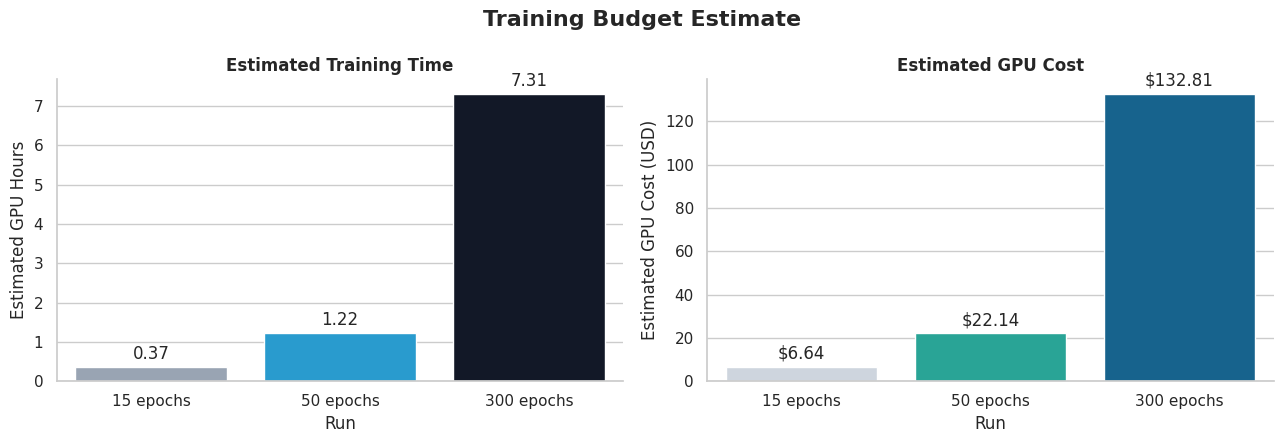

In [ ]:
cost_plot_df = cost_df.copy()
cost_hours_palette = {
    run: color
    for run, color in zip(cost_plot_df["Run"], ["#94a3b8", "#0ea5e9", "#0f172a"], strict=False)
}
cost_usd_palette = {
    run: color
    for run, color in zip(cost_plot_df["Run"], ["#cbd5e1", "#14b8a6", "#0369a1"], strict=False)
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(
    data=cost_plot_df,
    x="Run",
    y="Estimated GPU Hours",
    hue="Run",
    legend=False,
    ax=axes[0],
    palette=cost_hours_palette,
)
axes[0].set_title("Estimated Training Time")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=cost_plot_df,
    x="Run",
    y="Estimated GPU Cost (USD)",
    hue="Run",
    legend=False,
    ax=axes[1],
    palette=cost_usd_palette,
)
axes[1].set_title("Estimated GPU Cost")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="$%.2f", padding=3)

fig.suptitle("Training Budget Estimate", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

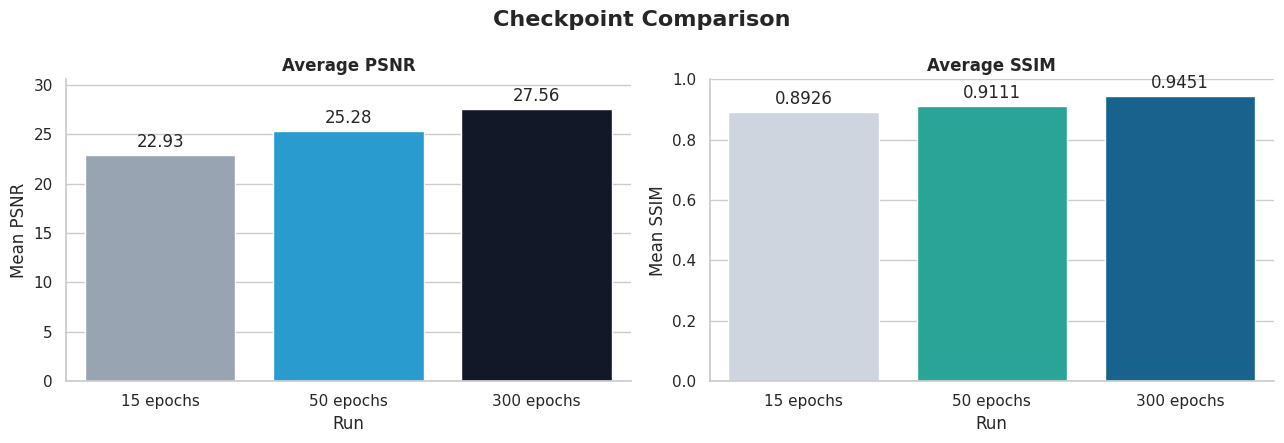

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
summary_psnr_palette = {
    run: color
    for run, color in zip(summary_df["Run"], ["#94a3b8", "#0ea5e9", "#0f172a"], strict=False)
}
summary_ssim_palette = {
    run: color
    for run, color in zip(summary_df["Run"], ["#cbd5e1", "#14b8a6", "#0369a1"], strict=False)
}

sns.barplot(
    data=summary_df,
    x="Run",
    y="Mean PSNR",
    hue="Run",
    legend=False,
    ax=axes[0],
    palette=summary_psnr_palette,
)
axes[0].set_title("Average PSNR")
axes[0].set_ylim(0, summary_df["Mean PSNR"].max() + 3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=summary_df,
    x="Run",
    y="Mean SSIM",
    hue="Run",
    legend=False,
    ax=axes[1],
    palette=summary_ssim_palette,
)
axes[1].set_title("Average SSIM")
axes[1].set_ylim(0, 1.0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.4f", padding=3)

fig.suptitle("Checkpoint Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

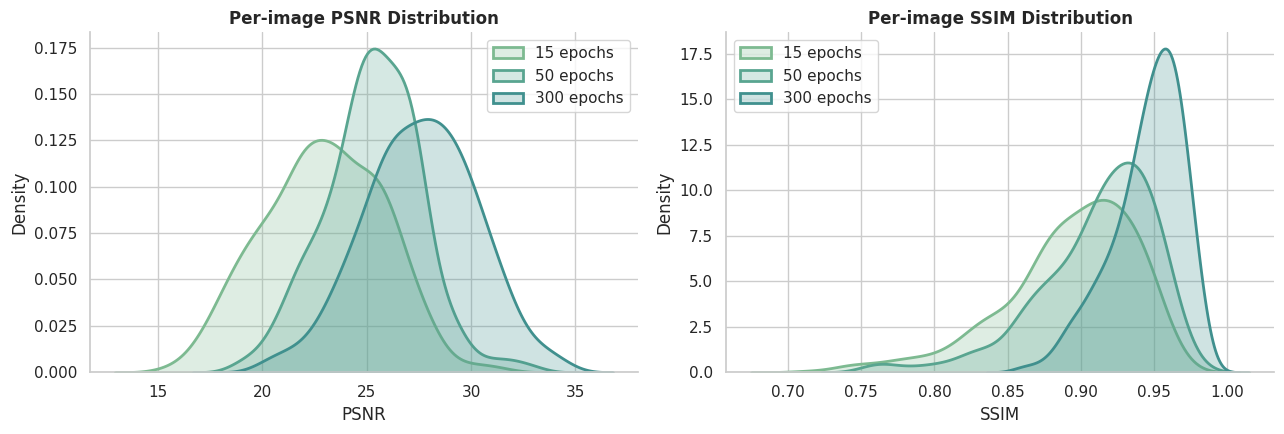

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for label, df in distributions.items():
    sns.kdeplot(df["psnr"], fill=True, common_norm=False, alpha=0.25, linewidth=2, label=label, ax=axes[0])
    sns.kdeplot(df["ssim"], fill=True, common_norm=False, alpha=0.25, linewidth=2, label=label, ax=axes[1])

axes[0].set_title("Per-image PSNR Distribution")
axes[0].set_xlabel("PSNR")
axes[1].set_title("Per-image SSIM Distribution")
axes[1].set_xlabel("SSIM")
axes[0].legend(frameon=True)
axes[1].legend(frameon=True)
plt.tight_layout()
plt.show()

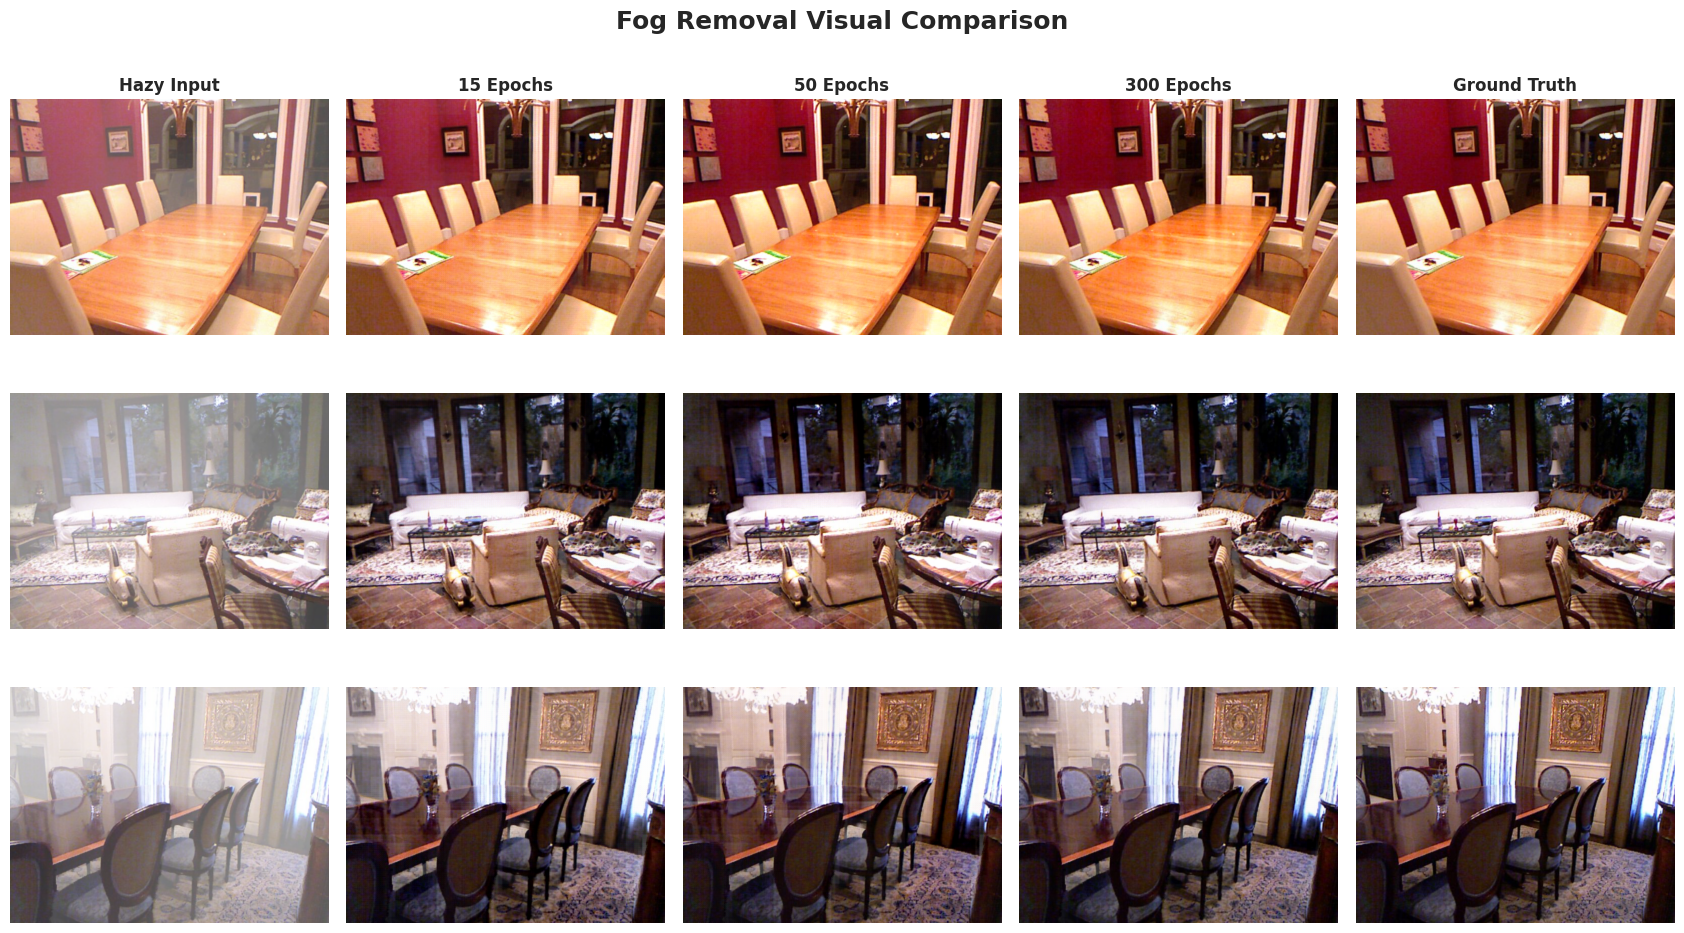

In [ ]:
samples = ["1400_1", "1425_5", "1449_10"]

def open_image(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")

cols = ["Hazy Input", "15 Epochs", "50 Epochs", "300 Epochs", "Ground Truth"]
fig, axes = plt.subplots(len(samples), 5, figsize=(17, 10))

for row, sample in enumerate(samples):
    image_paths = [
        ASSETS / "dataset" / f"{sample}_hazy.png",
        ASSETS / "15ep" / f"{sample}.png",
        ASSETS / "demo" / f"{sample}.png",
        ASSETS / "300ep" / f"{sample}.png",
        ASSETS / "dataset" / f"{sample}_gt.png",
    ]
    for col, (title, path) in enumerate(zip(cols, image_paths)):
        ax = axes[row, col]
        ax.imshow(open_image(path))
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=12, fontweight="bold")
        if col == 0:
            ax.set_ylabel(sample, fontsize=11, fontweight="bold")

fig.suptitle("Fog Removal Visual Comparison", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

            ## Final Inference Workflow

            This is the live deployment section of the notebook.

            Edit the paths below if you want to use your own video. By default, the notebook runs the final
            `300`-epoch checkpoint on the bundled foggy demo clip from `runs/test_assets/hazy.mp4`.
            

In [ ]:
FINAL_MODEL_NAME = "dehazeformer-s"
FINAL_CHECKPOINT = PROJECT_ASSETS["final_checkpoint"]
UPSTREAM_ROOT = ROOT / "external" / "dehazeformer"

INPUT_VIDEO = PROJECT_ASSETS["default_input_video"]
REFERENCE_VIDEO = PROJECT_ASSETS["default_reference_video"]
OUTPUT_ROOT = ROOT / "runs" / "notebook_demo"
OUTPUT_VIDEO = OUTPUT_ROOT / "dehazeformer_300ep_output.mp4"
OUTPUT_METRICS_JSON = OUTPUT_ROOT / "dehazeformer_300ep_metrics.json"
OUTPUT_REPORT_MD = OUTPUT_ROOT / "dehazeformer_300ep_report.md"

DEVICE = None  # set to "cpu" or "cuda" if you want to force it
TEMPORAL_ALPHA = 0.15
MAX_FRAMES = None  # set an int for a shorter dry run

{
    "input_video": str(INPUT_VIDEO),
    "reference_video": str(REFERENCE_VIDEO) if REFERENCE_VIDEO and Path(REFERENCE_VIDEO).exists() else None,
    "checkpoint": str(FINAL_CHECKPOINT),
    "upstream_root": str(UPSTREAM_ROOT),
    "output_video": str(OUTPUT_VIDEO),
    "device": DEVICE or "auto",
}

{'input_video': '/content/runs/test_assets/hazy.mp4',
 'reference_video': '/content/runs/test_assets/clear.mp4',
 'checkpoint': '/content/runs/modal/dehazeformer_s_reside_300ep/dehazeformer-s.pth',
 'upstream_root': '/content/external/dehazeformer',
 'output_video': '/content/runs/notebook_demo/dehazeformer_300ep_output.mp4',
 'device': 'auto'}

In [ ]:
if not Path(INPUT_VIDEO).exists():
    raise FileNotFoundError(f"Input video not found: {INPUT_VIDEO}")
if not Path(FINAL_CHECKPOINT).exists():
    raise FileNotFoundError(f"Final checkpoint not found: {FINAL_CHECKPOINT}")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
resolved_upstream = ensure_dehazeformer_upstream(UPSTREAM_ROOT)

start = time.time()
inference_result = process_video_with_dehazeformer(
    input_path=INPUT_VIDEO,
    output_path=OUTPUT_VIDEO,
    checkpoint_path=FINAL_CHECKPOINT,
    model_name=FINAL_MODEL_NAME,
    upstream_root=resolved_upstream,
    device=DEVICE,
    temporal_alpha=TEMPORAL_ALPHA,
    preserve_audio=True,
    reference_path=REFERENCE_VIDEO if Path(REFERENCE_VIDEO).exists() else None,
    max_frames=MAX_FRAMES,
)
inference_result["runtime_seconds"] = round(time.time() - start, 2)
write_json(OUTPUT_METRICS_JSON, inference_result)
write_markdown(OUTPUT_REPORT_MD, build_demo_markdown(inference_result, "Notebook Final Model Demo"))

inference_summary = pd.DataFrame(
    [{"Metric": key, "Value": value} for key, value in inference_result["summary"].items()]
)
display(inference_summary)
display(Markdown(f"**Runtime:** {inference_result['runtime_seconds']:.2f}s"))

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Dehazing video:   0%|          | 0/12 [00:00<?, ?frame/s]

,Metric,Value
0,input_contrast,14.310210
1,input_sharpness,18.365903
2,output_contrast,23.433407
3,output_sharpness,65.840351
4,psnr,25.711691
5,ssim,0.949082
6,frames,12.000000
7,fps,8.000000
8,width,160.000000
9,height,120.000000


**Runtime:** 15.11s

In [ ]:
RTTS_INPUT_DIR = ROOT / "data" / "RTTS"
RTTS_OUTPUT_DIR = ROOT / "runs" / "rtts_inference"
RTTS_METRICS_JSON = RTTS_OUTPUT_DIR / "rtts_inference_metrics.json"
RTTS_REPORT_MD = RTTS_OUTPUT_DIR / "rtts_inference_report.md"
RTTS_LIMIT = 12  # set to None for the full folder
RTTS_PATTERNS = ("*.png", "*.jpg", "*.jpeg", "*.bmp")
RTTS_SAMPLE_REPO = "Leoxuhan/RTTS_YOLO"
RTTS_SAMPLE_FILES = [
    "images/test/AM_Bing_217.png",
    "images/test/BD_Baidu_058.png",
    "images/test/BJ_Google_116.png",
    "images/test/CC_Bing_242.png",
    "images/test/CD_Google_135.png",
    "images/test/CQ_Google_615.png",
]

{
    "rtts_input_dir": str(RTTS_INPUT_DIR),
    "rtts_output_dir": str(RTTS_OUTPUT_DIR),
    "patterns": RTTS_PATTERNS,
    "limit": RTTS_LIMIT,
}

{'rtts_input_dir': '/content/data/RTTS',
 'rtts_output_dir': '/content/runs/rtts_inference',
 'patterns': ('*.png', '*.jpg', '*.jpeg', '*.bmp'),
 'limit': 12}

In [ ]:
def ensure_rtts_samples(input_root: Path) -> list[Path]:
    input_root.mkdir(parents=True, exist_ok=True)
    existing = sorted(
        path for path in input_root.iterdir()
        if path.is_file() and path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
    )
    if existing:
        return existing

    downloaded = []
    for remote_path in RTTS_SAMPLE_FILES:
        local_cache = hf_hub_download(
            repo_id=RTTS_SAMPLE_REPO,
            repo_type="dataset",
            filename=remote_path,
        )
        target = input_root / Path(remote_path).name
        shutil.copy2(local_cache, target)
        downloaded.append(target)
    return downloaded

ensure_rtts_samples(RTTS_INPUT_DIR)
print(f"RTTS images ready: {len(list(RTTS_INPUT_DIR.glob('*')))} files in {RTTS_INPUT_DIR}")

RTTS images ready: 6 files in /content/data/RTTS


In [ ]:
def process_image_directory_with_dehazeformer(
    input_root: Path,
    output_root: Path,
    checkpoint_path: Path,
    model_name: str,
    upstream_root: Path,
    device: str | None = None,
    patterns: tuple[str, ...] = ("*.png", "*.jpg", "*.jpeg", "*.bmp"),
    limit: int | None = None,
) -> dict[str, Any]:
    bundle = load_dehazeformer(
        checkpoint_path=checkpoint_path,
        model_name=model_name,
        upstream_root=upstream_root,
        device=device,
    )

    image_paths = []
    for pattern in patterns:
        image_paths.extend(path for path in input_root.rglob(pattern) if path.is_file())
    image_paths = sorted(dict.fromkeys(image_paths))
    if limit is not None:
        image_paths = image_paths[:limit]

    output_root.mkdir(parents=True, exist_ok=True)
    results = []
    aggregate = []

    for image_path in image_paths:
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image is None:
            continue
        restored = dehaze_frame(image, bundle)
        relative = image_path.relative_to(input_root)
        output_path = output_root / relative
        output_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(output_path), restored)

        metrics = {
            "input_contrast": contrast(image),
            "output_contrast": contrast(restored),
            "input_sharpness": sharpness(image),
            "output_sharpness": sharpness(restored),
            "width": float(image.shape[1]),
            "height": float(image.shape[0]),
        }
        aggregate.append(metrics)
        results.append(
            {
                "input_image": str(image_path),
                "output_image": str(output_path),
                "summary": metrics,
            }
        )

    summary = summarize_metrics(aggregate)
    summary["images"] = float(len(results))
    return {
        "input_root": str(input_root),
        "output_root": str(output_root),
        "checkpoint": str(checkpoint_path),
        "pipeline": {
            "mode": "dehazeformer-image-dir",
            "model_name": model_name,
            "device": bundle.device,
            "patterns": list(patterns),
        },
        "summary": summary,
        "images": results,
    }

In [ ]:
rtts_result = process_image_directory_with_dehazeformer(
    input_root=RTTS_INPUT_DIR,
    output_root=RTTS_OUTPUT_DIR,
    checkpoint_path=FINAL_CHECKPOINT,
    model_name=FINAL_MODEL_NAME,
    upstream_root=resolved_upstream,
    device=DEVICE,
    patterns=RTTS_PATTERNS,
    limit=RTTS_LIMIT,
)
write_json(RTTS_METRICS_JSON, rtts_result)
write_markdown(RTTS_REPORT_MD, build_demo_markdown(rtts_result, "RTTS Image Inference"))
display(pd.DataFrame([{"Metric": key, "Value": value} for key, value in rtts_result["summary"].items()]))

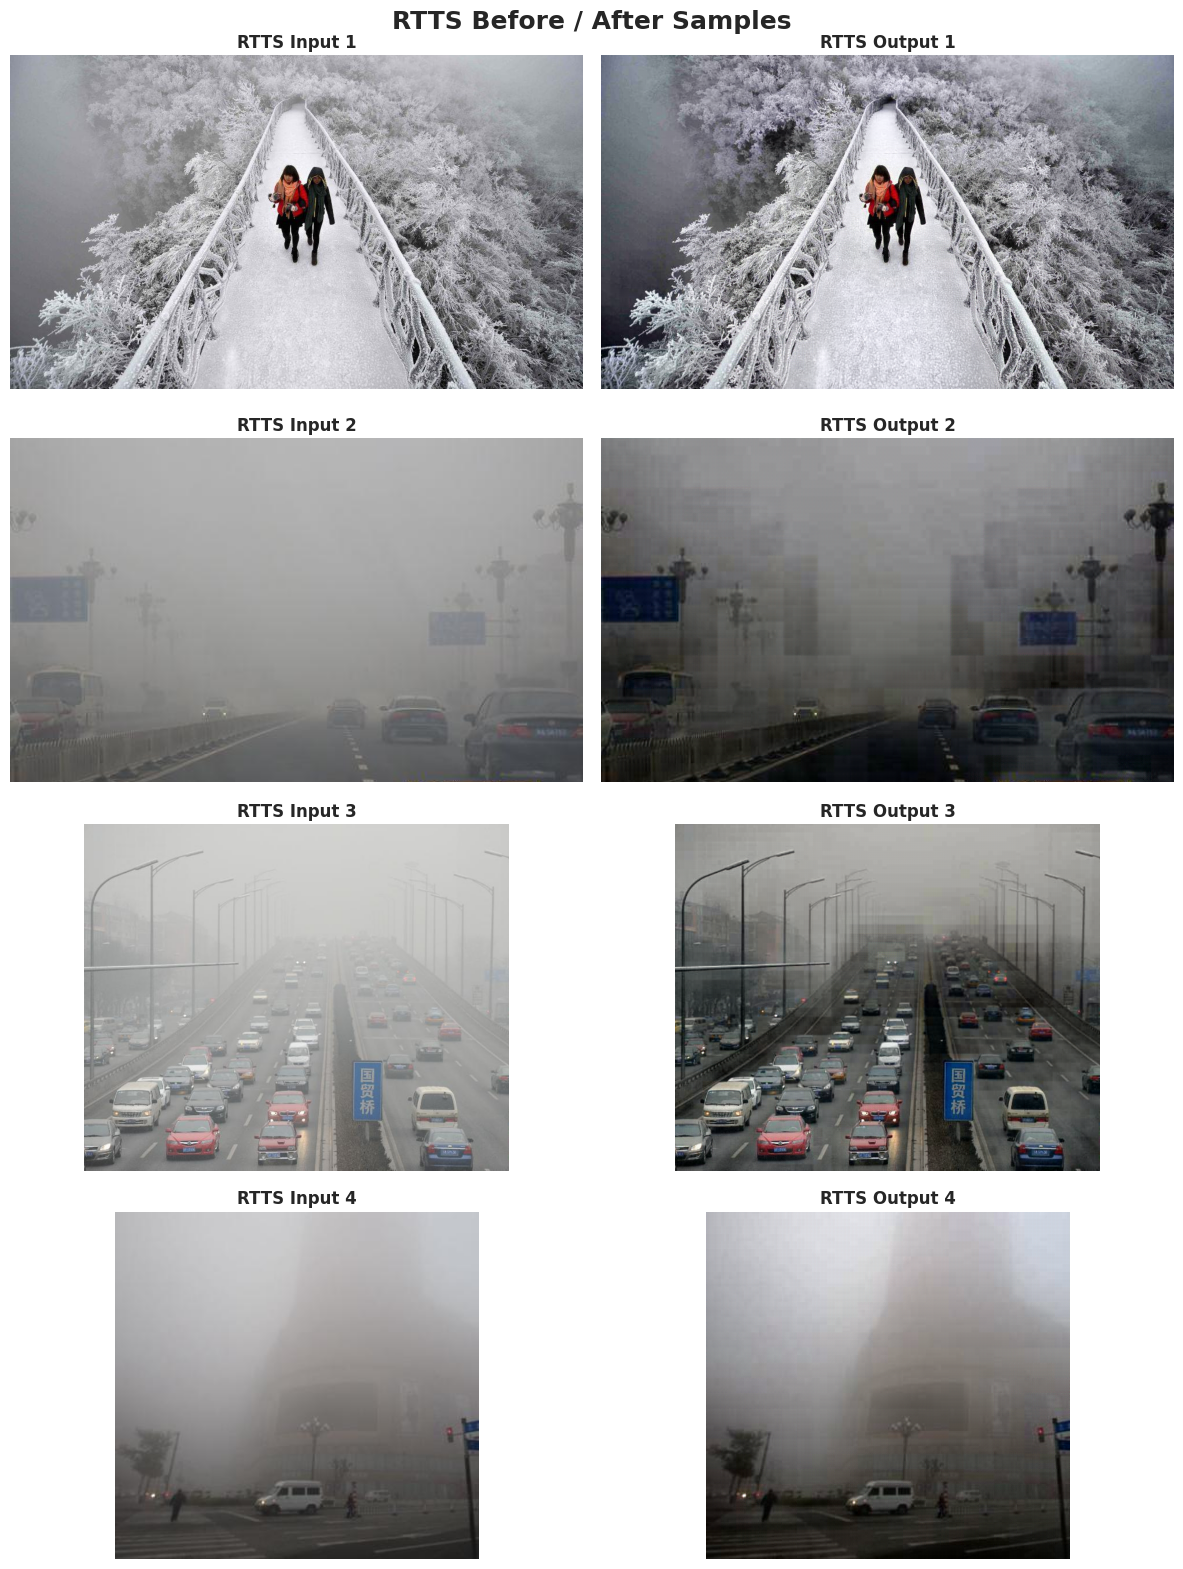

In [ ]:
if "rtts_result" in globals() and rtts_result["images"]:
    sample_items = rtts_result["images"][: min(4, len(rtts_result["images"]))]
    fig, axes = plt.subplots(len(sample_items), 2, figsize=(12, 4 * len(sample_items)))
    if len(sample_items) == 1:
        axes = np.array([axes])

    for row, item in enumerate(sample_items):
        input_image = cv2.cvtColor(cv2.imread(item["input_image"]), cv2.COLOR_BGR2RGB)
        output_image = cv2.cvtColor(cv2.imread(item["output_image"]), cv2.COLOR_BGR2RGB)
        axes[row, 0].imshow(input_image)
        axes[row, 0].axis("off")
        axes[row, 0].set_title(f"RTTS Input {row + 1}", fontweight="bold")
        axes[row, 1].imshow(output_image)
        axes[row, 1].axis("off")
        axes[row, 1].set_title(f"RTTS Output {row + 1}", fontweight="bold")

    fig.suptitle("RTTS Before / After Samples", fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.show()

            ## Deployment Notes

            The inference path in this notebook is designed for project usability:
            - it can run on CPU for short demos,
            - it will use GPU automatically if available,
            - it exports both the result video and machine-readable metrics,
            - it keeps the final checkpoint as the single deployment artifact.

            That makes the notebook a practical project handoff artifact, not just a presentation document.
            

In [ ]:
display(Markdown("### Input / Output Video Preview"))
display(Video(str(INPUT_VIDEO), embed=False))
display(Video(str(OUTPUT_VIDEO), embed=False))

### Input / Output Video Preview

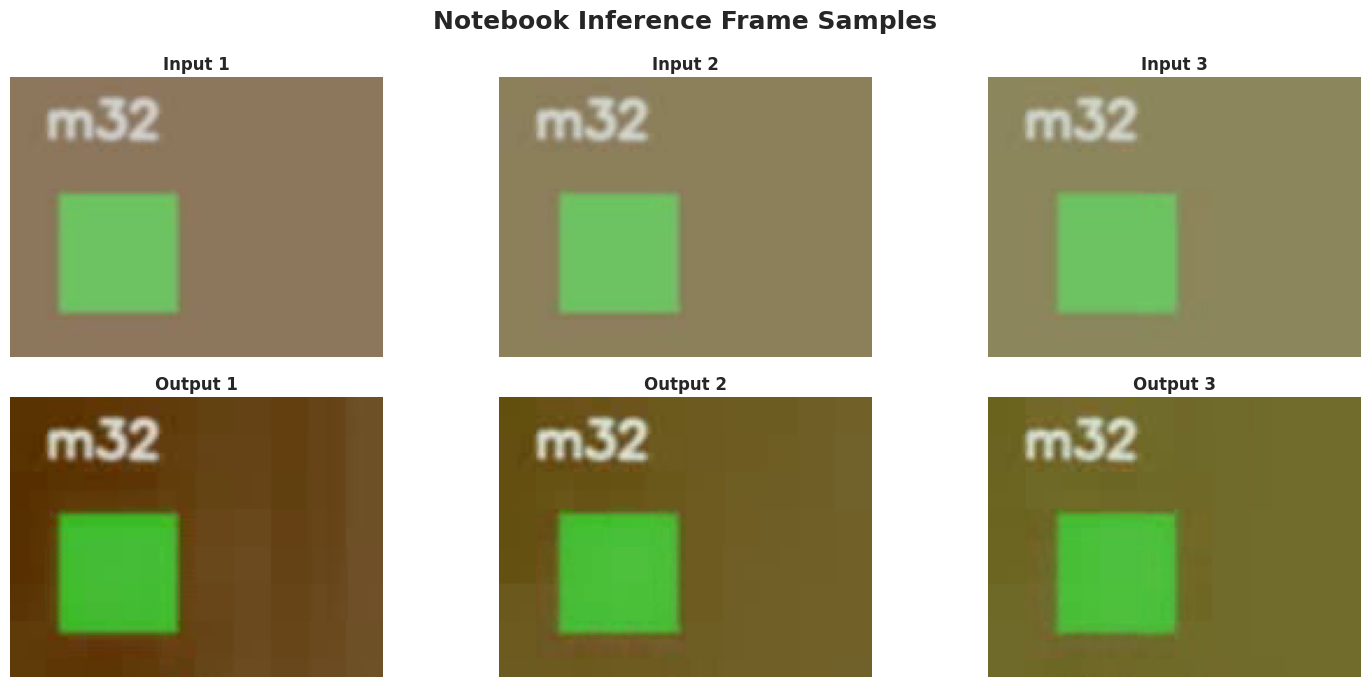

In [ ]:
def sample_frames(video_path: Path, positions=(0.15, 0.5, 0.85)):
    cap = cv2.VideoCapture(str(video_path))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    for pos in positions:
        index = max(0, min(frame_count - 1, int(frame_count * pos)))
        cap.set(cv2.CAP_PROP_POS_FRAMES, index)
        ok, frame = cap.read()
        if ok:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

input_frames = sample_frames(Path(INPUT_VIDEO))
output_frames = sample_frames(Path(OUTPUT_VIDEO))

fig, axes = plt.subplots(2, len(input_frames), figsize=(15, 7))
for idx, frame in enumerate(input_frames):
    axes[0, idx].imshow(frame)
    axes[0, idx].axis("off")
    axes[0, idx].set_title(f"Input {idx + 1}", fontweight="bold")
for idx, frame in enumerate(output_frames):
    axes[1, idx].imshow(frame)
    axes[1, idx].axis("off")
    axes[1, idx].set_title(f"Output {idx + 1}", fontweight="bold")

fig.suptitle("Notebook Inference Frame Samples", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
final_outputs = pd.DataFrame(
    [
        {"Artifact": "Final checkpoint", "Path": str(FINAL_CHECKPOINT)},
        {"Artifact": "Inference video", "Path": str(OUTPUT_VIDEO)},
        {"Artifact": "Inference metrics JSON", "Path": str(OUTPUT_METRICS_JSON)},
        {"Artifact": "Inference markdown report", "Path": str(OUTPUT_REPORT_MD)},
    ]
)
display(final_outputs.style.hide(axis="index"))

Artifact,Path
Final checkpoint,/content/runs/modal/dehazeformer_s_reside_300ep/dehazeformer-s.pth
Inference video,/content/runs/notebook_demo/dehazeformer_300ep_output.mp4
Inference metrics JSON,/content/runs/notebook_demo/dehazeformer_300ep_metrics.json
Inference markdown report,/content/runs/notebook_demo/dehazeformer_300ep_report.md


In [ ]:
resolved_upstream = ensure_dehazeformer_upstream(UPSTREAM_ROOT)

bundle = load_dehazeformer(
    checkpoint_path=FINAL_CHECKPOINT,
    model_name=FINAL_MODEL_NAME,
    upstream_root=resolved_upstream,
    device=DEVICE,
)

print("Model loaded:", bundle.model_name, "on", bundle.device)

Model loaded: dehazeformer-s on cuda


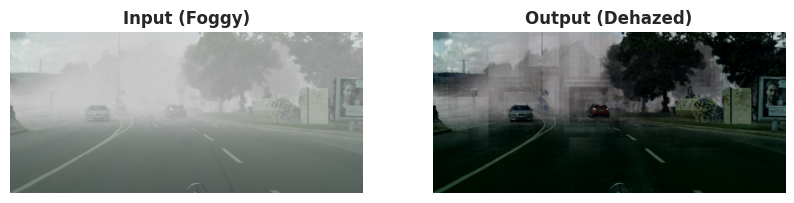

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = "/content/Fog1 (10).png"

img = cv2.imread(img_path)

output = dehaze_frame(img, bundle)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input (Foggy)")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Output (Dehazed)")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [ ]:
import subprocess
from IPython.display import Video

input_video = "/content/12562964_1080_1920_30fps.mp4"
demo_video = "demo_small.mp4"
raw_output_video = "dehazed_output_raw.mp4"
final_output_video = "dehazed_output_h264.mp4"

subprocess.run([
    "ffmpeg", "-y",
    "-i", input_video,
    "-vf", "scale=640:360",
    "-t", "3",
    "-an",
    demo_video
], check=True)

print("Prepared small demo video")

demo_result = process_video_with_dehazeformer(
    input_path=demo_video,
    output_path=raw_output_video,
    checkpoint_path=FINAL_CHECKPOINT,
    model_name=FINAL_MODEL_NAME,
    upstream_root=resolved_upstream,
    device=DEVICE,
    temporal_alpha=TEMPORAL_ALPHA,
    preserve_audio=False,
    max_frames=60,
)

print("\nProcessing Summary:")
print(demo_result["summary"])

subprocess.run([
    "ffmpeg", "-y",
    "-i", raw_output_video,
    "-vcodec", "libx264",
    "-pix_fmt", "yuv420p",
    final_output_video
], check=True)

print("\nRe-encoded output video for display")

Video(final_output_video, embed=True)

In [ ]:
Video(demo_video, embed=True)
